In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
import os
import pickle

## Data preparation

In [14]:
IMG_SIZE = 224 
BATCH_SIZE = 64 
EPOCHS = 5

TRAIN_DIR = "/kaggle/input/fer2013/train"
VAL_DIR = "/kaggle/input/fer2013/test"

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,            
    rotation_range=10,
    horizontal_flip=True,
    validation_split=0.5
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True,
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
print("Classes found:", class_names)

Found 14357 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Classes found: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## MobileNetV2 model

In [10]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False, 
    weights='imagenet'
)
base_model.trainable = False # Freeze initially

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(512)(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128)(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model = models.Model(inputs, outputs)

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,985,543 (11.39 MB)

 Trainable params: 724,999 (2.77 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [15]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 251s 1s/step - accuracy: 0.3022 - loss: 1.9285 - val_accuracy: 0.2503 - val_loss: 1.8332
Epoch 2/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 181s 806ms/step - accuracy: 0.3479 - loss: 1.6964 - val_accuracy: 0.3175 - val_loss: 1.7147
Epoch 3/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 187s 832ms/step - accuracy: 0.3724 - loss: 1.6407 - val_accuracy: 0.3801 - val_loss: 1.5921
Epoch 4/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 186s 827ms/step - accuracy: 0.3952 - loss: 1.5955 - val_accuracy: 0.3885 - val_loss: 1.6017
Epoch 5/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 181s 806ms/step - accuracy: 0.3999 - loss: 1.5692 - val_accuracy: 0.4015 - val_loss: 1.5729


## Download the model

In [16]:
from IPython.display import FileLink
model_name = 'emotion_model.keras'
model.save(model_name)

# Save labels
with open('emotion_labels.pkl', 'wb') as f:
    pickle.dump(class_names, f)

print(f"\n✅ Model saved as {model_name}")
display(FileLink(model_name))
display(FileLink('emotion_labels.pkl'))


✅ Model saved as emotion_model.keras


/kaggle/working/emotion_model.keras

/kaggle/working/emotion_labels.pkl

## Evaluation

Preparing Test Data for Evaluation...
Found 7178 images belonging to 7 classes.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Running Predictions on Test Set...
113/113 ━━━━━━━━━━━━━━━━━━━━ 26s 205ms/step

Generating Confusion Matrix...


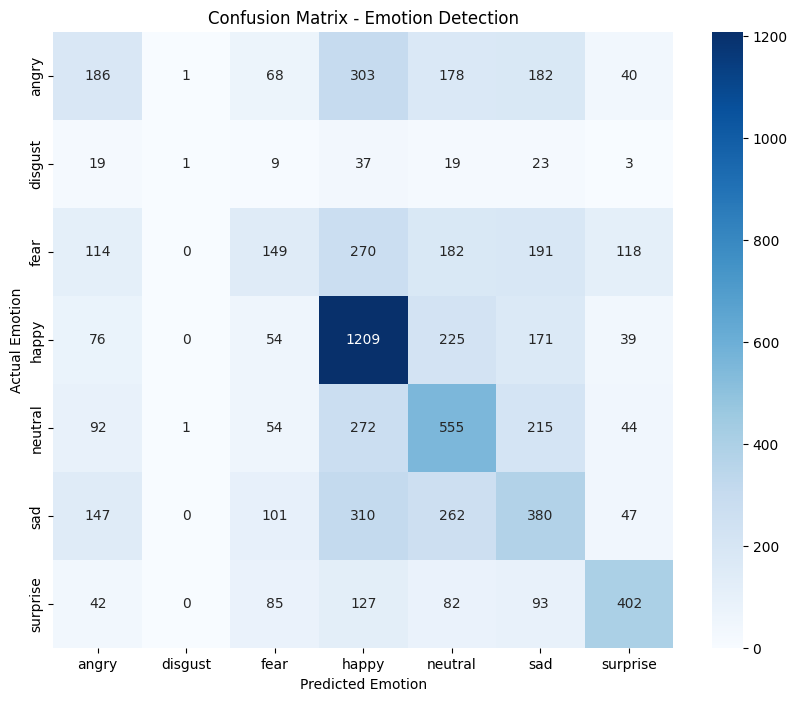


--- Detailed Classification Report ---
              precision    recall  f1-score   support

       angry       0.28      0.19      0.23       958
     disgust       0.33      0.01      0.02       111
        fear       0.29      0.15      0.19      1024
       happy       0.48      0.68      0.56      1774
     neutral       0.37      0.45      0.41      1233
         sad       0.30      0.30      0.30      1247
    surprise       0.58      0.48      0.53       831

    accuracy                           0.40      7178
   macro avg       0.38      0.32      0.32      7178
weighted avg       0.38      0.40      0.38      7178

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step


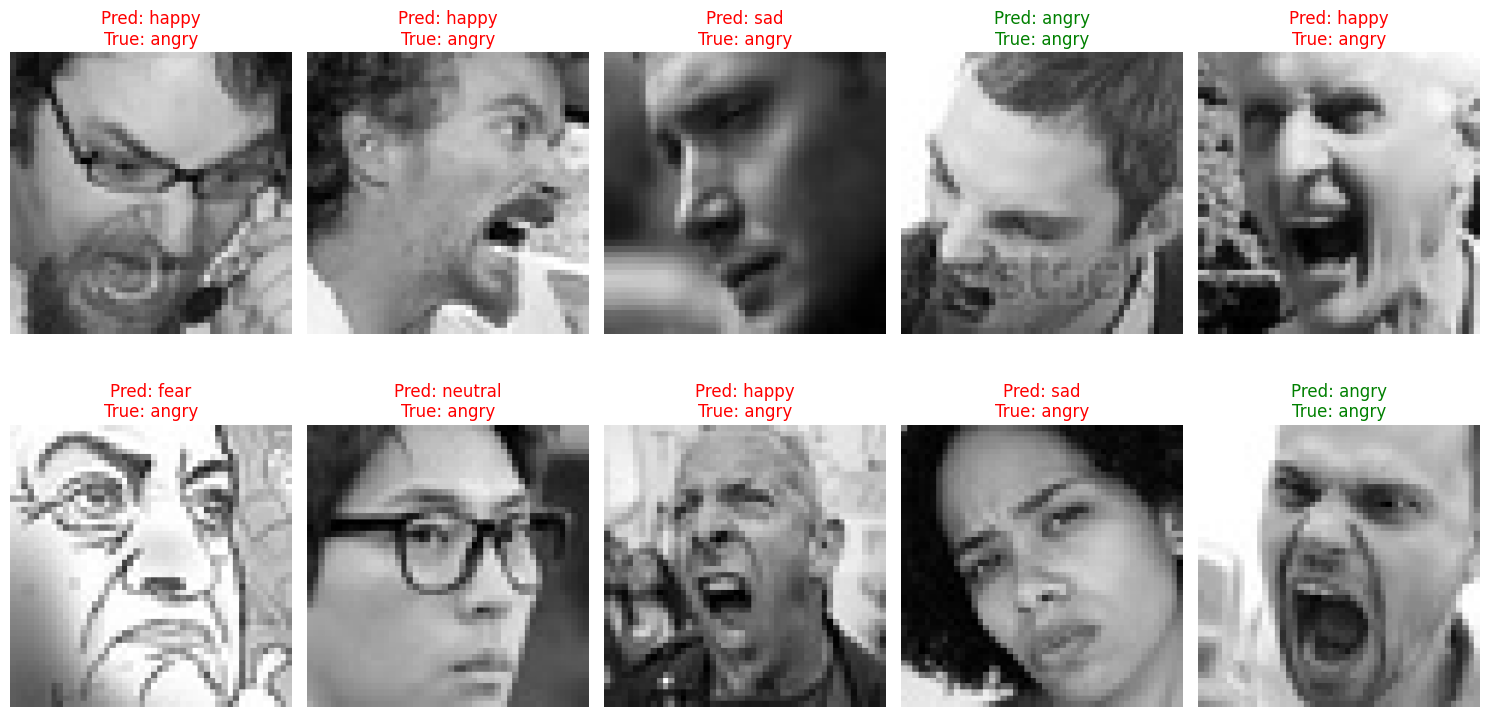

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

print("Preparing Test Data for Evaluation...")

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    "/kaggle/input/fer2013/test", # Using the test set
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False 
)

# Get class labels
class_names = list(test_generator.class_indices.keys())
print(f"Classes: {class_names}")

print("Running Predictions on Test Set...")
# Get probabilities
y_pred_probs = model.predict(test_generator, verbose=1)
# Get predicted class index (0-6)
y_pred = np.argmax(y_pred_probs, axis=1)
# Get true labels
y_true = test_generator.classes

print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual Emotion')
plt.xlabel('Predicted Emotion')
plt.title('Confusion Matrix - Emotion Detection')
plt.show()

print("\n--- Detailed Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

imgs, labels = next(test_generator)
preds = model.predict(imgs)

plt.figure(figsize=(15, 8))
for i in range(10): # Show first 10 images of the batch
    plt.subplot(2, 5, i+1)
    plt.imshow(imgs[i])
    
    pred_label = class_names[np.argmax(preds[i])]
    true_label = class_names[np.argmax(labels[i])]
    
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()